Accuracy: 0.7415730337078652
ROC-AUC: 0.8262626262626263


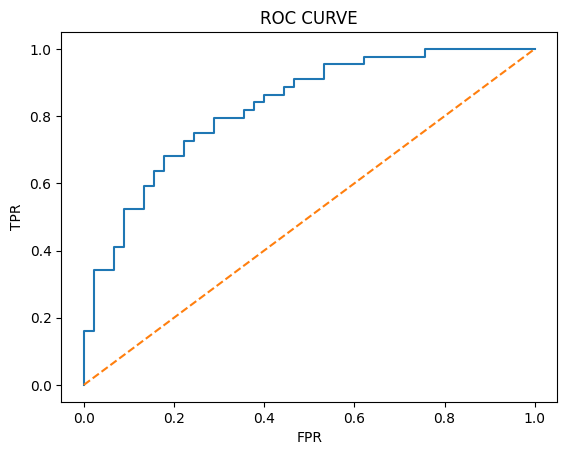

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

df = pd.read_csv("Healthcare-diseases.csv")

df["outcome"] = (df["target"] > df["target"].median()).astype(int)

x = df.drop(["target", "outcome"], axis=1)

y = df["outcome"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

y_prob = model.predict_proba(x_test)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("FPR")

plt.ylabel("TPR")

plt.title("ROC CURVE")

plt.show()